In [1]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 67.6 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from Bio import SeqIO
from collections import defaultdict

Реализация функции compute_cpg_ratio:

In [13]:
def compute_cpg_ratio(window):
    """
    Вычисляет параметры для окна последовательности:
    - P(CG) - частота динуклеотида CG
    - P(C) и P(G) - частоты отдельных нуклеотидов
    - R(CG) = P(CG) / (P(C) * P(G))
    - GC% - процент G и C
    """
    window = window.upper()
    window_len = len(window)

    if window_len < 2:
        return {'P_CG': 0, 'P_C': 0, 'P_G': 0, 'R_CG': 0, 'GC_percent': 0}

    count_C = window.count('C')
    count_G = window.count('G')
    count_CG = 0

    for i in range(window_len - 1):
        if window[i:i+2] == 'CG':
            count_CG += 1

    P_C = count_C / window_len
    P_G = count_G / window_len
    P_CG = count_CG / (window_len - 1)  # количество динуклеотидов = длина - 1

    # Вычисление R(CG) с защитой от деления на ноль
    if P_C * P_G > 0:
        R_CG = P_CG / (P_C * P_G)
    else:
        R_CG = 0

    GC_percent = (count_C + count_G) * 100 / window_len

    return {
        'P_CG': P_CG,
        'P_C': P_C,
        'P_G': P_G,
        'R_CG': R_CG,
        'GC_percent': GC_percent,
        'count_CG': count_CG,
        'count_C': count_C,
        'count_G': count_G
    }


Буду использовать первую хромосому человека:

In [14]:
filename = "sequence (1).fasta"

In [15]:
with open(filename) as handle:
    for record in SeqIO.parse(handle, "fasta"):
        sequence = str(record.seq[:100000]).upper()
        print(f"Загружено: {record.id}")
        print(f"Длина последовательности: {len(sequence)} нуклеотидов")
        break

Загружено: NC_000001.11
Длина последовательности: 100000 нуклеотидов


In [52]:
window_size = 200
step = 50

In [53]:
results = []
positions = []

Скользим окном:

In [54]:
for i in range(0, len(sequence) - window_size + 1, step):
    window = sequence[i:i + window_size]
    stats = compute_cpg_ratio(window)
    results.append(stats)
    positions.append(i + window_size // 2)

Находим все окна, удовлетворяющие условиям:

In [55]:
candidate_windows = []
for i, (pos, stats) in enumerate(zip(positions, results)):
    if stats['R_CG'] > 0.6 and stats['GC_percent'] > 50:
        candidate_windows.append({
            'start': pos - window_size // 2,
            'end': pos + window_size // 2,
            'center': pos,
            'R_CG': stats['R_CG'],
            'GC_percent': stats['GC_percent']
        })

In [56]:
total_C = sequence.count('C')
total_G = sequence.count('G')
total_CG = sum(1 for i in range(len(sequence)-1) if sequence[i:i+2] == 'CG')
total_len = len(sequence)

print(f"  Количество C: {total_C} ({total_C/total_len*100:.2f}%)")
print(f"  Количество G: {total_G} ({total_G/total_len*100:.2f}%)")
print(f"  GC состав: {(total_C+total_G)/total_len*100:.2f}%")
print(f"  Количество CG динуклеотидов: {total_CG}")

  Количество C: 19924 (19.92%)
  Количество G: 18283 (18.28%)
  GC состав: 38.21%
  Количество CG динуклеотидов: 1101


Объединяем перекрывающиеся окна в островки:

In [57]:
def merge_windows(windows, max_gap=100):
    if not windows:
        return []

    # Сортируем по начальной позиции
    windows.sort(key=lambda x: x['start'])

    merged = []
    current = windows[0]

    for window in windows[1:]:
        if window['start'] <= current['end'] + max_gap:  # Перекрываются или рядом
            current['end'] = max(current['end'], window['end'])
            current['R_CG'] = max(current['R_CG'], window['R_CG'])
            current['GC_percent'] = max(current['GC_percent'], window['GC_percent'])
        else:
            merged.append(current)
            current = window

    merged.append(current)
    return merged

cpg_islands = merge_windows(candidate_windows)

print(f"\nНайдено CpG островков: {len(cpg_islands)}")



Найдено CpG островков: 6


Находим координаты островков:

In [62]:
if cpg_islands:
    print(f"{'Начало':<12} {'Конец':<12} {'Длина':<8} {'R(CG) макс':<12}")

    for island in cpg_islands:
        length = island['end'] - island['start']
        island_r_values = []
        for i, pos in enumerate(positions):
            if island['start'] <= pos <= island['end']:
                if results[i]['R_CG'] > 0.6 and results[i]['GC_percent'] > 50:
                    island_r_values.append(results[i]['R_CG'])
        avg_r = np.mean(island_r_values) if island_r_values else 0

        print(f"{island['start']:<12} {island['end']:<12} {length:<8} "
              f"{island['R_CG']:<12.3f}")

Начало       Конец        Длина    R(CG) макс  
10300        11300        1000     1.343       
26750        26950        200      0.603       
28650        29800        1150     1.143       
36800        37000        200      0.603       
51450        51950        500      0.932       
88350        88650        300      0.647       


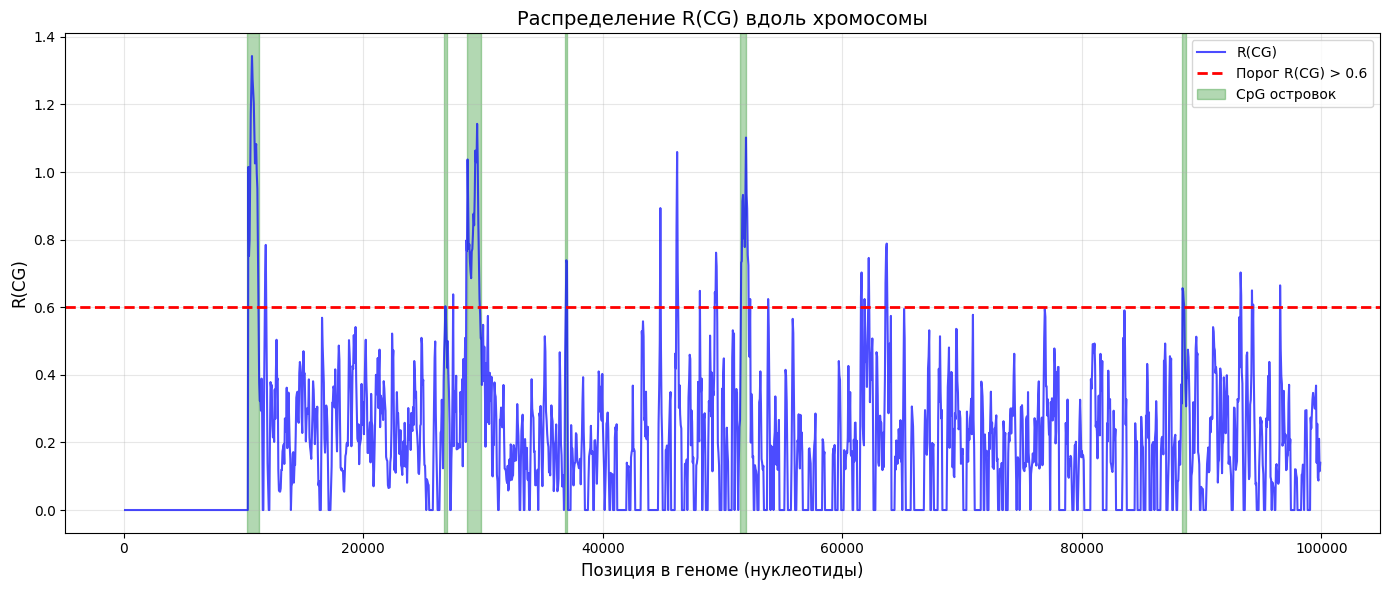

In [45]:
plt.figure(figsize=(14, 6))

r_values = [r['R_CG'] for r in results]

plt.plot(positions, r_values, 'b-', linewidth=1.5, alpha=0.7, label='R(CG)')

plt.axhline(y=0.6, color='r', linestyle='--', linewidth=2, label='Порог R(CG) > 0.6')

if cpg_islands:
    for island in cpg_islands:
        plt.axvspan(island['start'], island['end'], alpha=0.3, color='green',
                   label='CpG островок' if island == cpg_islands[0] else "")

plt.xlabel('Позиция в геноме (нуклеотиды)', fontsize=12)
plt.ylabel('R(CG)', fontsize=12)
plt.title('Распределение R(CG) вдоль хромосомы', fontsize=14)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()